In [ ]:
# Análise Exploratória de Dados (EDA) - Chamados ANEEL
#**Objetivo:** Explorar o dataset processado para identificar padrões, distribuições de chamados por distribuidora/tipologia,
# analisar o desbalanceamento da variável alvo e investigar a correlação entre o dia da semana de abertura e o estouro do SLA.

SyntaxError: invalid syntax (675695758.py, line 2)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Caminho do dataset limpo
PROCESSED_PATH = '../data/processed/dataset_limpo.csv'

# Carregamento dos dados
df = pd.read_csv(PROCESSED_PATH)
print(f"Dataset carregado com sucesso! Formato: {df.shape}")
df.head()

Dataset carregado com sucesso! Formato: (65231, 10)


,Distribuidora,Protocolo,Natureza,Tipologia,CanalEntrada,tempo_resolucao_dias,estourou_sla,dia_semana_abertura,hora_abertura,mes_abertura
0,ENEL CE,103365732169,RECLAMAÇÃO,Cobrança Indevida,Fale Conosco,1847.001013,1,2,10,3
1,CEMIG,104752952314,RECLAMAÇÃO,Conexão de Mini e Microgeração,Fale Conosco,952.929651,1,3,16,8
2,CEMIG,104765912332,RECLAMAÇÃO,Alteração de carga,Fale Conosco,910.847000,1,1,15,8
3,ENEL RJ,104869582371,RECLAMAÇÃO,Extensão de Rede,Fale Conosco,799.166548,1,3,13,11
4,CEMIG,104892392311,RECLAMAÇÃO,Extensão de Rede,Fale Conosco,771.125887,1,2,12,11


C:\Users\Luis Eletro\AppData\Local\Temp\ipykernel_20228\3219437051.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Distribuidora', order=order_dist, ax=axes[0], palette='viridis')
C:\Users\Luis Eletro\AppData\Local\Temp\ipykernel_20228\3219437051.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Tipologia', order=order_tipo, ax=axes[1], palette='flare')


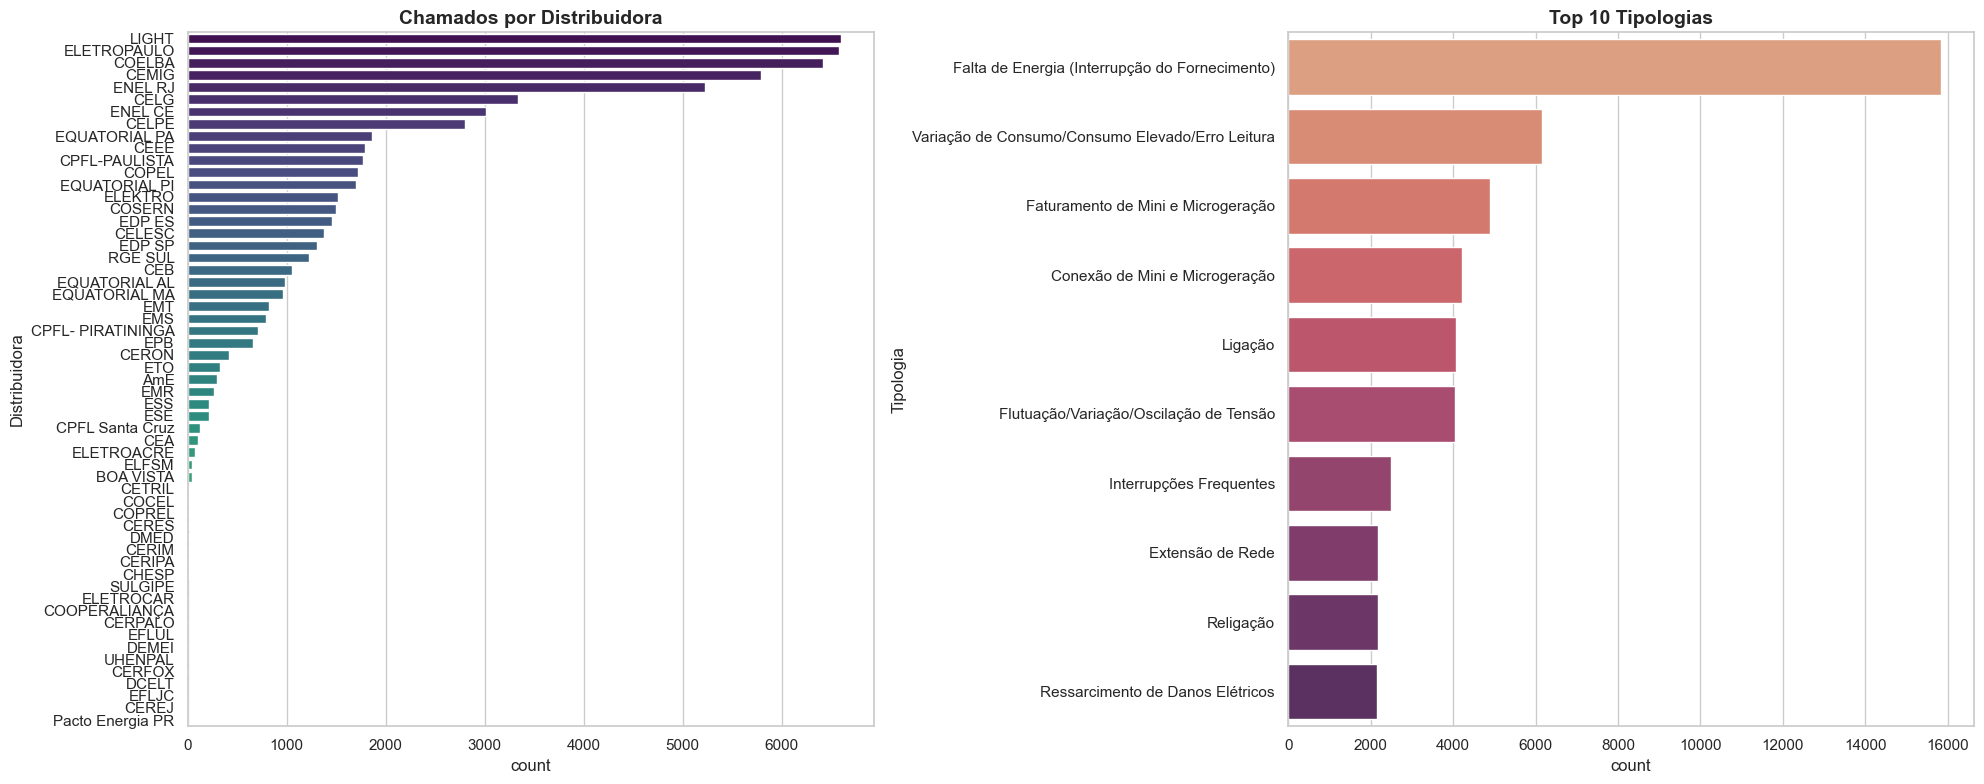

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

order_dist = df['Distribuidora'].value_counts().index
sns.countplot(data=df, y='Distribuidora', order=order_dist, ax=axes[0], palette='viridis')
axes[0].set_title('Chamados por Distribuidora', fontsize=14, fontweight='bold')

order_tipo = df['Tipologia'].value_counts().head(10).index
sns.countplot(data=df, y='Tipologia', order=order_tipo, ax=axes[1], palette='flare')
axes[1].set_title('Top 10 Tipologias', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Luis Eletro\AppData\Local\Temp\ipykernel_20228\3235177033.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=contagem.index, y=contagem.values, palette='Blues_r')


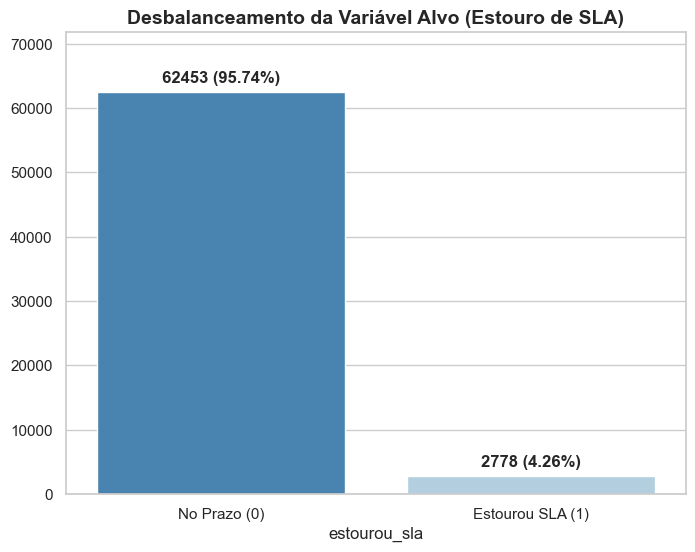

In [3]:
contagem = df['estourou_sla'].value_counts()
porcentagens = df['estourou_sla'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=contagem.index, y=contagem.values, palette='Blues_r')

for i, p in enumerate(ax.patches):
    texto = f"{contagem.values[i]} ({porcentagens.values[i]:.2f}%)"
    ax.annotate(texto, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.title('Desbalanceamento da Variável Alvo (Estouro de SLA)', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['No Prazo (0)', 'Estourou SLA (1)'])
plt.ylim(0, max(contagem.values) * 1.15)
plt.show()

C:\Users\Luis Eletro\AppData\Local\Temp\ipykernel_20228\4036505082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=dias_nomes, y=taxa_estouro_dia.values, palette='coolwarm')


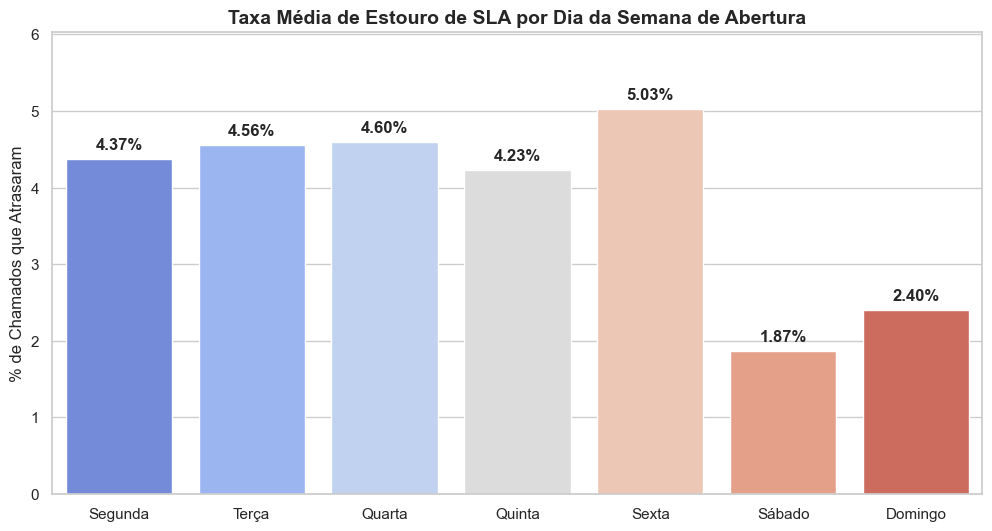

In [4]:
taxa_estouro_dia = df.groupby('dia_semana_abertura')['estourou_sla'].mean() * 100
dias_nomes = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=dias_nomes, y=taxa_estouro_dia.values, palette='coolwarm')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.title('Taxa Média de Estouro de SLA por Dia da Semana de Abertura', fontsize=14, fontweight='bold')
plt.ylabel('% de Chamados que Atrasaram')
plt.ylim(0, max(taxa_estouro_dia.values) * 1.2)
plt.show()